In [ ]:
############### Customer Report
# Importing Necessary libraries
import pyodbc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import urllib
from sqlalchemy import create_engine

server = 'LAPTOP-LFBT0G3K'
database = 'DataWarehouse'
driver = '{ODBC Driver 18 for SQL Server}'

In [2]:
try:
    quoted_driver = urllib.parse.quote_plus(driver)
    connection_uri = (
        f'mssql+pyodbc:///?odbc_connect='
        f'DRIVER={quoted_driver};'
        f'SERVER={server};'
        f'DATABASE={database};'
        f'Trusted_Connection=yes;'
        f'Encrypt=yes;'
        f'TrustServerCertificate=yes;'
    )
    sql_analysis_query="""
                            WITH base_query AS(
                            -- 1) Base Query: Retrieves core columns from tables
                                SELECT
                                    f.order_number,
                                    f.product_key,
                                    f.order_date,
                                    f.sales_amount,
                                    f.quantity,
                                    c.customer_key,
                                    CONCAT(c.first_name, ' ', c.last_name) AS customer_name,
                                    DATEDIFF(year, c.birthdate, GETDATE()) age
                                
                                FROM gold.fact_sales f
                                LEFT JOIN gold.dim_customer c
                                
                                ON c.customer_key = f.customer_key
                                WHERE order_date IS NOT NULL),

                            customer_aggregation AS (
                            -- 2) Customer Aggregations: Summarizes key metrics at the customer level
                                SELECT
                                    customer_key,
                                    customer_name,
                                    age,
                                    COUNT(DISTINCT order_number) AS total_orders,
                                    SUM(sales_amount) AS total_sales,
                                    SUM(quantity) AS total_quantity,
                                    COUNT(DISTINCT product_key) AS total_products,
                                    MAX(order_date) AS last_order_date,
                                    DATEDIFF(month, MIN(order_date), MAX(order_date)) AS lifespan

                                FROM base_query
                                GROUP BY
                                    customer_key,
                                    customer_name,
                                    age
                                )

                            SELECT
                                customer_key,
                                customer_name,
                                age,
                                
                                CASE
                                    WHEN age < 20 THEN 'Under 20'
                                    WHEN age between 20 and 29 THEN '20-29'
                                    WHEN age between 30 and 39 THEN '30-39'
                                    WHEN age between 40 and 49 THEN '40-49'
                                    ELSE '50 and above'
                                END AS age_group,
                                
                                CASE
                                    WHEN lifespan >= 12 AND total_sales > 5000 THEN 'VIP'
                                    WHEN lifespan >= 12 AND total_sales <= 5000 THEN 'Regular'
                                    ELSE 'New'
                                END AS customer_segment,
                                
                                last_order_date,
                                DATEDIFF(month, last_order_date, GETDATE()) AS recency,
                                total_orders,
                                total_sales,
                                total_quantity,
                                total_products
                                lifespan,

                            -- Compute average order value (AVO)
                            CASE WHEN total_sales = 0 THEN 0
                                ELSE total_sales / total_orders
                            END AS avg_order_value,

                            -- Compute average monthly spend
                            CASE WHEN lifespan = 0 THEN total_sales
                                ELSE total_sales / lifespan
                            END AS avg_monthly_spend
                            FROM customer_aggregation;
    """
    print(f"Attempting to connect to {server}/{database} using driver: {driver}")
    engine = create_engine(connection_uri)
    print("Successfully connected to SQL Server!")
    
    df_customer_report=pd.read_sql(sql_analysis_query,engine)


except Exception as e:
    print(f"An unexpected error occurred: {e}")

Attempting to connect to LAPTOP-LFBT0G3K/DataWarehouse using driver: {ODBC Driver 18 for SQL Server}
Successfully connected to SQL Server!


In [3]:
# Test for Data
print('first 5 rows fo sales analysis Data : ')
print(df_customer_report.head())
print('\nSales Analysis Data info : ')
print(df_customer_report.info())

first 5 rows fo sales analysis Data : 
   customer_key      customer_name   age     age_group customer_segment  \
0             1           Jon Yang  54.0  50 and above              VIP   
1             2       Eugene Huang  49.0         40-49              VIP   
2             3       Ruben Torres  54.0  50 and above              VIP   
3             4        Christy Zhu  52.0  50 and above              VIP   
4             5  Elizabeth Johnson  46.0         40-49              VIP   

  last_order_date  recency  total_orders  total_sales  total_quantity  \
0      2013-05-03      144             3         8249               8   
1      2013-12-10      137             3         6384              11   
2      2013-02-23      147             3         8114               4   
3      2013-05-10      144             3         8139               9   
4      2013-05-01      144             3         8196               6   

   lifespan  avg_order_value  avg_monthly_spend  
0         8          

In [10]:
print("--- Distinct Categories using .unique() ---")
distinct_categories = df_customer_report['age_group'].unique()
print(distinct_categories)

--- Distinct Categories using .unique() ---
['50 and above' '40-49' '30-39']


C:\Users\Ayush\AppData\Local\Temp\ipykernel_15708\2094702999.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='customer_segment', y='total_sales', data=segment_sales, palette='viridis')


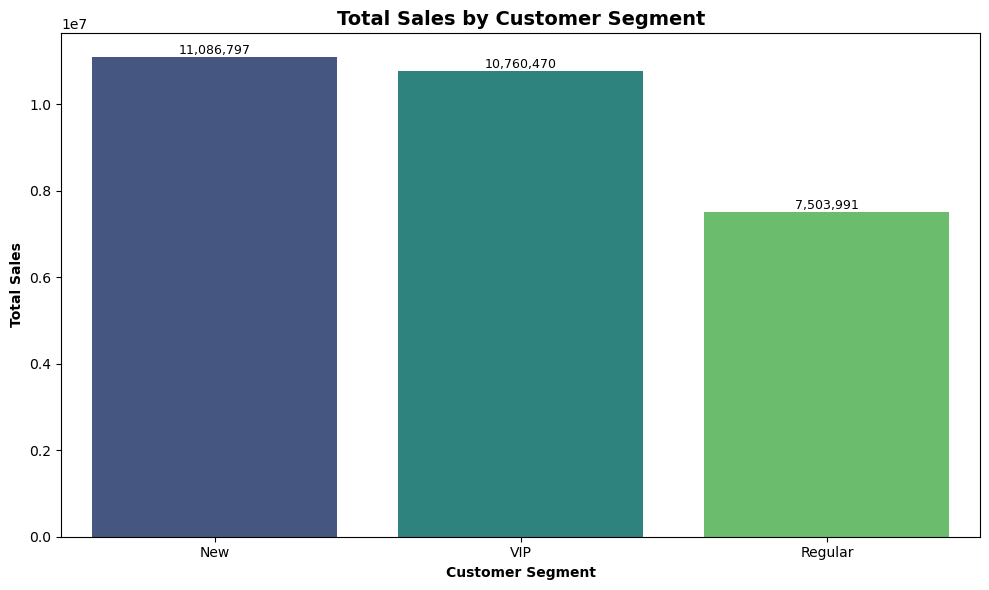

C:\Users\Ayush\AppData\Local\Temp\ipykernel_15708\2094702999.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='age_group', y='total_sales', data=age_group_sales, palette='viridis')


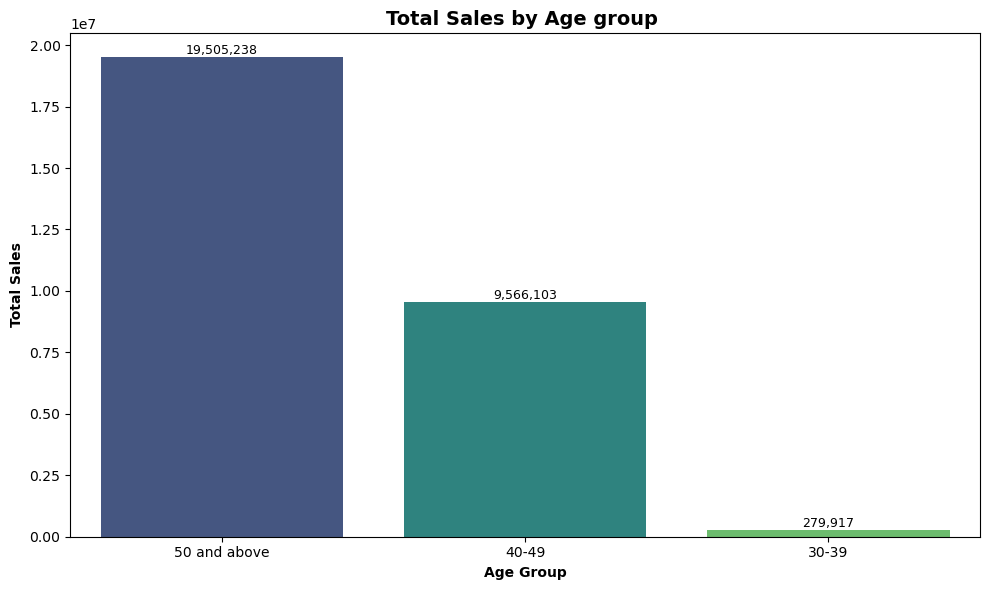

In [18]:
plt.figure(figsize=(10, 6))
segment_sales = df_customer_report.groupby('customer_segment').agg(total_sales=('total_sales', 'sum'),total_quantity=('total_quantity', 'sum')).reset_index().sort_values(by='total_sales', ascending=False)

sns.barplot(x='customer_segment', y='total_sales', data=segment_sales, palette='viridis')
plt.title('Total Sales by Customer Segment', fontweight='bold', fontsize=14)
plt.xlabel('Customer Segment', fontweight='bold')
plt.ylabel('Total Sales', fontweight='bold')
for bar in plt.gca().patches:
    plt.gca().text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{bar.get_height():,.0f}',ha='center', va='bottom', fontsize=9, color='black')
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 6))
age_group_sales = df_customer_report.groupby('age_group').agg(total_sales=('total_sales', 'sum'),total_quantity=('total_quantity', 'sum')).reset_index().sort_values(by='total_sales', ascending=False)

sns.barplot(x='age_group', y='total_sales', data=age_group_sales, palette='viridis')
plt.title('Total Sales by Age group ', fontweight='bold', fontsize=14)
plt.xlabel('Age Group', fontweight='bold')
plt.ylabel('Total Sales', fontweight='bold')
for bar in plt.gca().patches:
    plt.gca().text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{bar.get_height():,.0f}',ha='center', va='bottom', fontsize=9, color='black')
plt.tight_layout()
plt.show()


C:\Users\Ayush\AppData\Local\Temp\ipykernel_15708\3852219788.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='customer_segment', y='total_quantity', data=segment_sales, palette='magma_r')


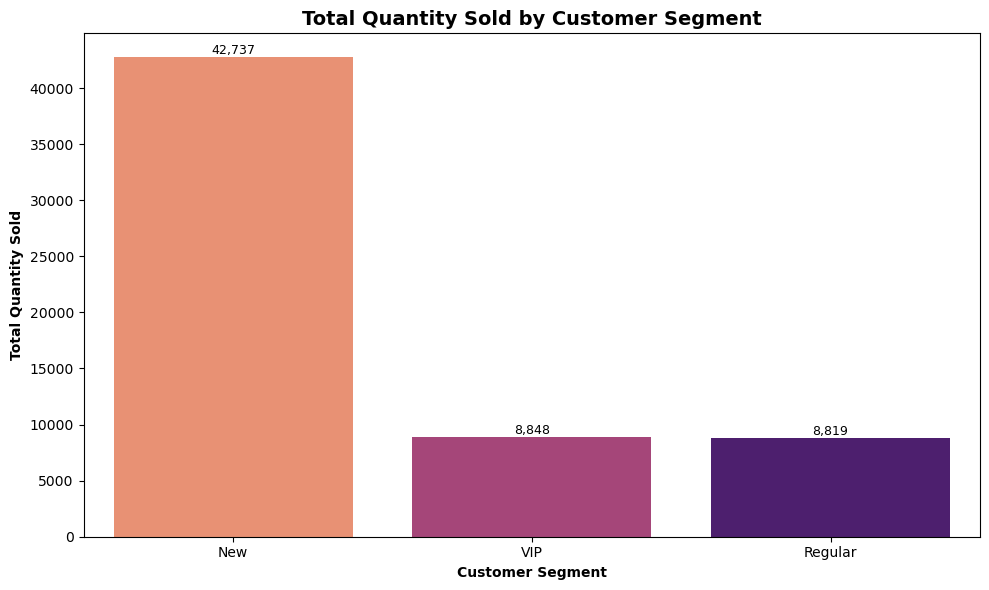

C:\Users\Ayush\AppData\Local\Temp\ipykernel_15708\3852219788.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='age_group', y='total_quantity', data=age_group_sales, palette='magma_r')


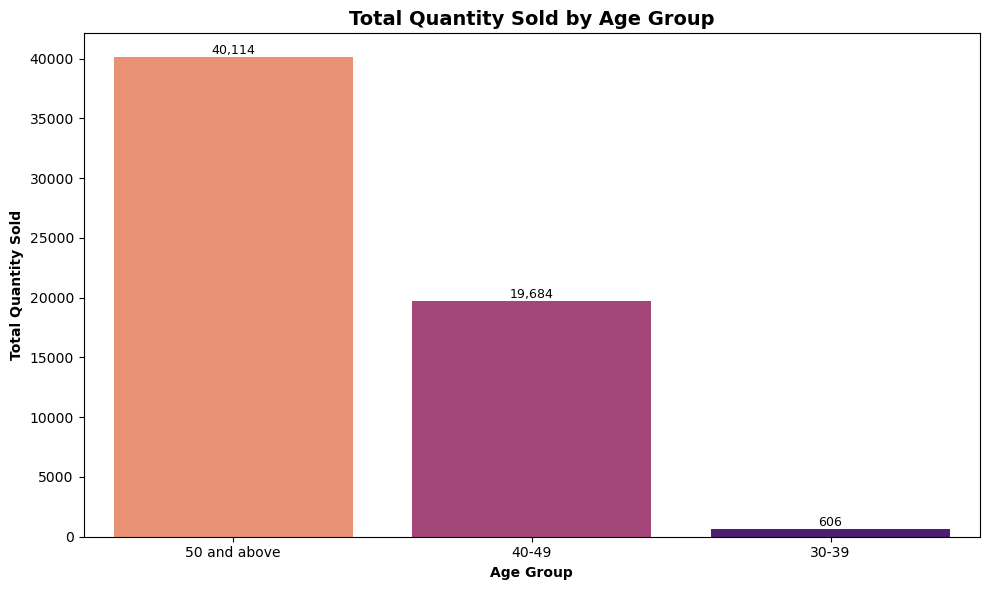

In [20]:
plt.figure(figsize=(10, 6))
sns.barplot(x='customer_segment', y='total_quantity', data=segment_sales, palette='magma_r')
plt.title('Total Quantity Sold by Customer Segment', fontweight='bold', fontsize=14)
plt.xlabel('Customer Segment', fontweight='bold')
plt.ylabel('Total Quantity Sold', fontweight='bold')
for bar in plt.gca().patches:
    plt.gca().text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{bar.get_height():,.0f}',ha='center', va='bottom', fontsize=9, color='black')
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 6))
sns.barplot(x='age_group', y='total_quantity', data=age_group_sales, palette='magma_r')
plt.title('Total Quantity Sold by Age Group', fontweight='bold', fontsize=14)
plt.xlabel('Age Group', fontweight='bold')
plt.ylabel('Total Quantity Sold', fontweight='bold')
for bar in plt.gca().patches:
    plt.gca().text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{bar.get_height():,.0f}',ha='center', va='bottom', fontsize=9, color='black')
plt.tight_layout()
plt.show()

C:\Users\Ayush\AppData\Local\Temp\ipykernel_15708\1392430711.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='customer_segment', y='avg_monthly_spend', data=avg_monthly_spend_by_segment,order=segment_order, palette=colors)


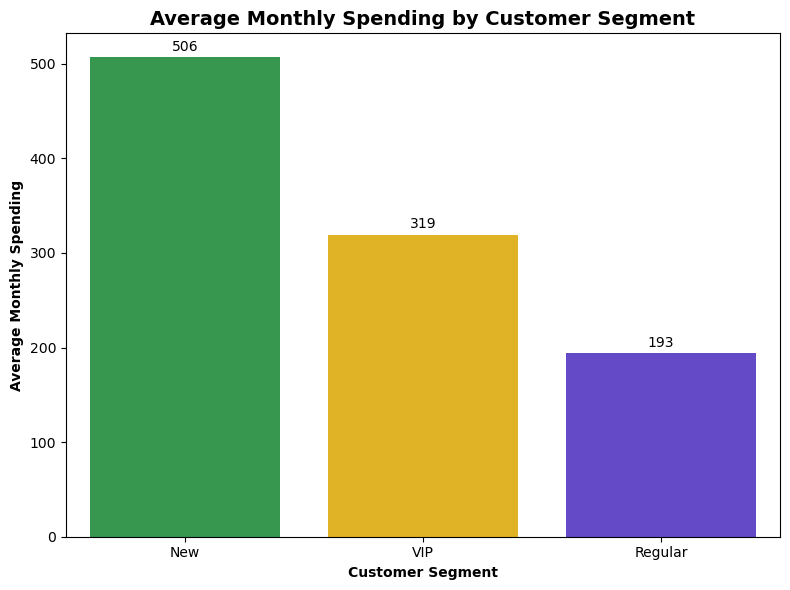

C:\Users\Ayush\AppData\Local\Temp\ipykernel_15708\1392430711.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='customer_segment', y='avg_monthly_spend', data=avg_monthly_spend_by_age_group,order=segment_order, palette=colors)


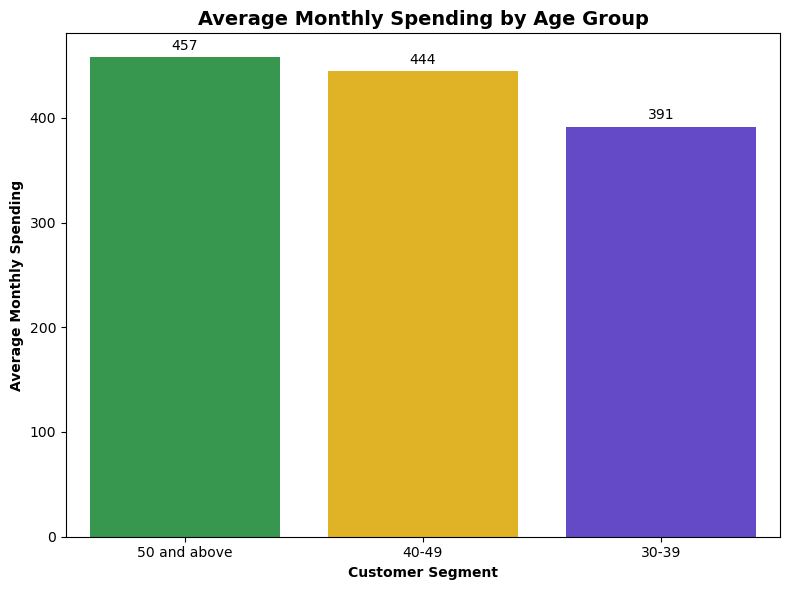

In [34]:
plt.figure(figsize=(8, 6))
avg_monthly_spend_by_segment = df_customer_report.groupby('customer_segment')['avg_monthly_spend'].mean().reset_index()
avg_monthly_spend_by_segment.columns = ['customer_segment', 'avg_monthly_spend']

segment_order = ['New', 'VIP', 'Regular']
colors = ['#28a745', '#ffc107', "#5935dc"]

ax = sns.barplot(x='customer_segment', y='avg_monthly_spend', data=avg_monthly_spend_by_segment,order=segment_order, palette=colors)

plt.title('Average Monthly Spending by Customer Segment', fontweight='bold', fontsize=14)
plt.xlabel('Customer Segment',fontweight='bold')
plt.ylabel('Average Monthly Spending',fontweight='bold')

for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width() / 2,bar.get_height() + 4,f'{int(bar.get_height())}',ha='center', va='bottom',fontsize=10, color='black')
plt.tight_layout()
plt.show()




plt.figure(figsize=(8, 6))
avg_monthly_spend_by_age_group = df_customer_report.groupby('age_group')['avg_monthly_spend'].mean().reset_index()
avg_monthly_spend_by_age_group.columns = ['customer_segment', 'avg_monthly_spend']

segment_order = ['50 and above','40-49','30-39']
colors = ['#28a745', '#ffc107', "#5935dc"]

ax = sns.barplot(x='customer_segment', y='avg_monthly_spend', data=avg_monthly_spend_by_age_group,order=segment_order, palette=colors)

plt.title('Average Monthly Spending by Age Group', fontweight='bold', fontsize=14)
plt.xlabel('Customer Segment',fontweight='bold')
plt.ylabel('Average Monthly Spending',fontweight='bold')

for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width() / 2,bar.get_height() + 4,f'{int(bar.get_height())}',ha='center', va='bottom',fontsize=10, color='black')
plt.tight_layout()
plt.show()